In [1]:
# os
import os
import pathlib

# Computations
import numpy as np
import scipy as sp
import sympy as smp

# Science
import CoolProp.CoolProp as CP
import gsw

# System
import yaml

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Data handling
import pandas as pd



In [2]:
### Should be run from inside the project
if __name__ == "__main__":
    # project name
    PROJECT_NAME = "ProjectAquarium"

    path = os.getcwd()
    while True:
        if os.path.basename(path) == PROJECT_NAME:
            PROJECT_PATH = path
            break

        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("ProjectAquarium not found")

        path = parent

In [3]:
sns.set_theme()
plt.rcParams['text.usetex'] = True

In [4]:
# aliases
norm = sp.linalg.norm
pi = np.pi

# Indices
XIND = 0
YIND = 1

# Physical parameters
with open(os.path.join(PROJECT_PATH, "design/aquarium/aquarium.yaml"), "r") as file:
    aquarium_params = yaml.safe_load(file)

# aquarium_params
H = aquarium_params["aquarium"]["main_box"]["z_inner"] / 1000   # convert to meters

In [5]:
# constants (SI)
g0 = sp.constants.g     # At sea level
p0 = sp.constants.atm   # At sea level
T_room = 290            # Israeli winter temperature in Kelvin

seasurface_density = CP.PropsSI('D', 'T', T_room, 'P', p0, 'Water')
viscosity = CP.PropsSI('VISCOSITY', 'T', T_room, 'P', p0, 'Water')  # Pa.s
kinematic_viscosity = viscosity / seasurface_density
seawater_surface_tension = 0.074  # N/m, estimate for seawater, +-0.001

# aliases
rho = seasurface_density
mu = viscosity
nu = kinematic_viscosity
tau = seawater_surface_tension


In [6]:
print("density = ", rho, "\nsurface_tension = ", tau)

density =  998.8039147159017 
surface_tension =  0.074


## complex dispersion == dispersion + damping

In [7]:
# Dispersion relation, capillary-gravity, short waves limit.
def dr_cg_sw(k):
    k = norm(k, axis=-1)
    return np.sqrt((g0 * k + tau/rho * k**3))

In [8]:
N = int(2e3)
k_max = 2*np.pi*int(2e2)
k_ps = np.linspace(k_max/N, k_max, num=N).reshape((N,1))
k_ps_abs = norm(k_ps, axis=-1)

In [9]:
def f_omega(omega, k):
    lhs = (2 - 1j*omega/(nu*k**2))**2 + (k*(g0 + tau/rho * k**2)) / (nu**2 * k**4)
    rhs = 4 * np.sqrt(1 - 1j*omega/(nu*k**2))
    return lhs - rhs

# --- Solver for one k ---
def solve_for_k(k):
    # initial guess: inviscid dispersion relation
    k_abs = norm(k, axis=-1)
    omega0 = np.sqrt(g0*k_abs + tau/rho*k_abs**3)
    # solve numerically
    sol = sp.optimize.newton(func=lambda w: f_omega(w, k_abs), x0=omega0, maxiter=1000, tol=1e-10)
    return sol

omegas = np.array([solve_for_k(k) for k in k_ps])


In [10]:
frequencies = np.real(omegas)/(2*pi)
decay_rates = np.imag(omegas)

In [156]:
# alternative no decay

ks_abs_alt = np.zeros(len(omegas))

for i in range(N):
    f = frequencies[i]
    def dispersion_kp(k):
        return (g0*k + (tau/rho)*k**3)*np.tanh(H*k) - (2*pi*f)**2

    if f < 13.45: 
        k_p_guess = (2*pi*f)**2 / g0
    else:
        k_p_guess = ((2*pi*f)**2 * rho/tau)**(1/3)
    k_lbound = k_p_guess/3
    k_rbound = 3*k_p_guess

    sol = sp.optimize.root_scalar(
        dispersion_kp, x0=k_p_guess, 
        bracket=[k_lbound, k_rbound],
        method="brentq"
        )

    # error checking
    if not sol.converged:
        raise RuntimeError(f"Root not found for k_p")
    ks_abs_alt[i] = sol.root


### dispersion (inverted): wavenumber vs. frequency

Text(0, 0.5, '$\\frac{|k|}{2\\pi} [cm^{-1}]$')

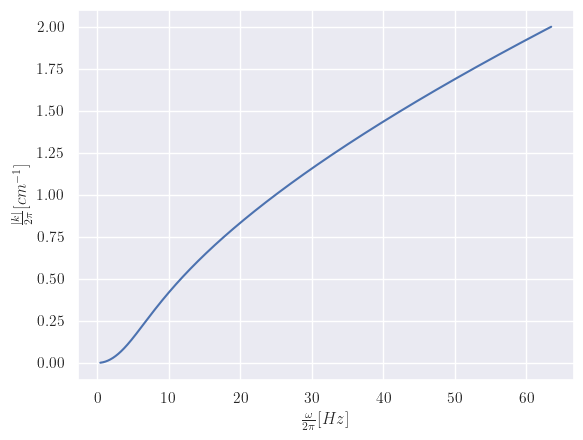

In [11]:
plt.plot(frequencies, norm(k_ps, axis=-1)/(2*np.pi)/100)
# plt.xlim(0, 50)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0, 200/100)
plt.ylabel(r"$\frac{|k|}{2\pi} [cm^{-1}]$")

### group velocity vs. frequency

Text(6.393221655171044, 17.832751699173013, '(6.39, 17.83)')

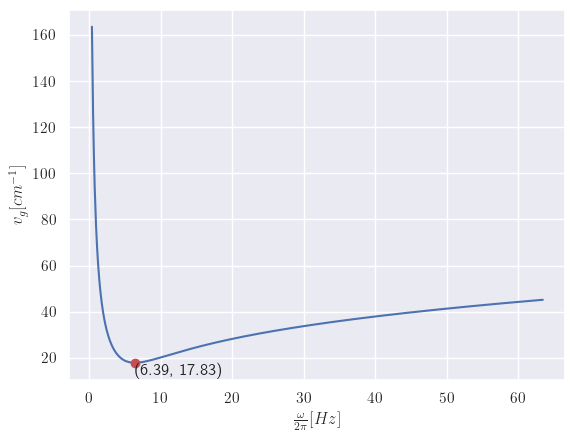

In [12]:
dwdks = np.diff(frequencies)/np.diff(norm(k_ps, axis=-1)/(2*np.pi)/100)
plt.plot(frequencies[:-1], dwdks)
# plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0,0.1)
plt.ylabel(r"$v_g [cm^{-1}]$")
i_min = np.argmin(dwdks)
w_min = frequencies[i_min]
v_min = dwdks[i_min]
plt.plot([w_min], [v_min], 'ro')
plt.text(w_min, v_min, f"({w_min:.2f}, {v_min:.2f})", fontsize=12, ha='left', va='top')


### Bond number vs. frequency

1.0001204958571663


Text(0, 0.5, 'tension/gravity contribution ratio')

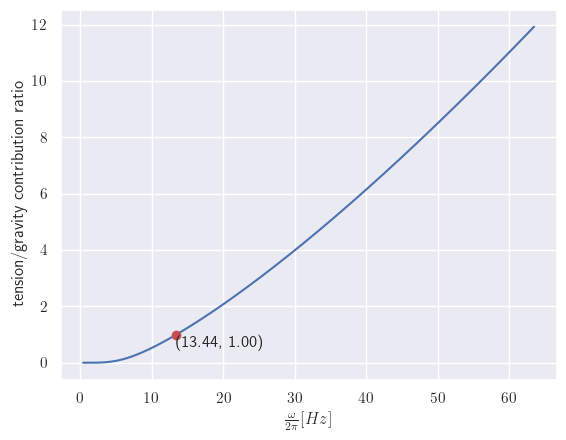

In [13]:
Bo = rho*g0 / (tau * k_ps**2)
plt.plot(frequencies, 1/Bo)
i_equal = np.argmin((Bo-1)**2)
f_equal = frequencies[i_equal]
Bo_equal = Bo[i_equal][0]
print(Bo_equal)
plt.plot([f_equal], [Bo_equal], 'ro')
plt.text(f_equal, Bo_equal, f"({f_equal:.2f}, {Bo_equal:.2f})", fontsize=12, ha='left', va='top')
# plt.xlim(0, 30)
# plt.ylim(0, 4)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylabel("tension/gravity contribution ratio")

Text(0, 0.5, 'tension - gravity contribution ratio')

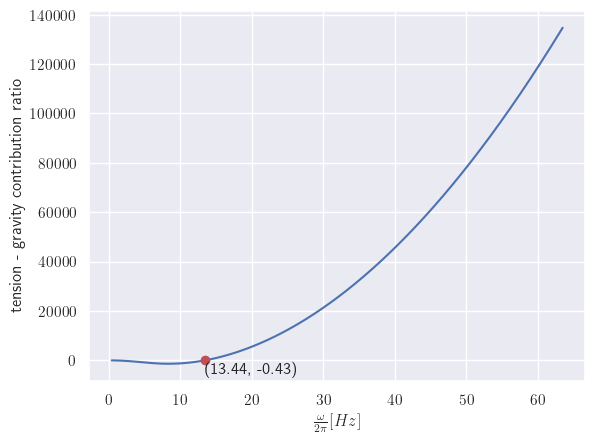

In [14]:
# yet another tension vs gravity comparison graph
c_g_diff = tau/rho * k_ps_abs**3 - g0 * k_ps_abs
plt.plot(frequencies, c_g_diff)
i_equal = np.argmin(c_g_diff[frequencies<20]**2)
f_equal = frequencies[i_equal]
c_g_diff_equal = c_g_diff[i_equal]
plt.plot([f_equal], [c_g_diff_equal], 'ro')
plt.text(f_equal, c_g_diff_equal, f"({f_equal:.2f}, {c_g_diff_equal:.2f})", fontsize=12, ha='left', va='top')
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylabel("tension - gravity contribution ratio")

### phase velocity vs frequency

Text(0, 0.5, '$v_{phase}[ms^{-1}]$')

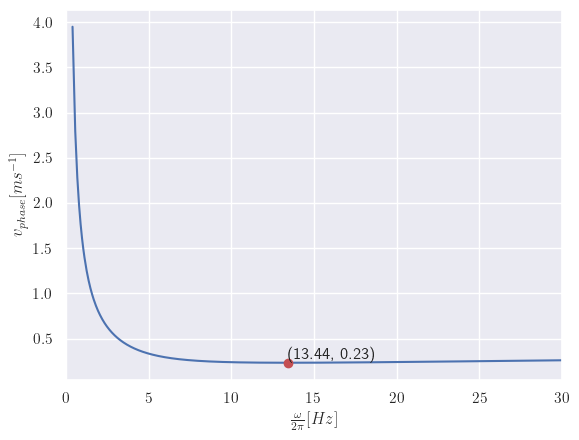

In [15]:
N = int(1e3)
k_max = 2*np.pi*int(1e3)
vs = np.real(omegas)/norm(k_ps, axis=-1)
plt.plot(frequencies, vs)

i_min = np.argmin(vs)
w_min = frequencies[i_min]
v_min = vs[i_min]
plt.plot([w_min], [v_min], 'ro')
plt.text(w_min, v_min, f"({w_min:.2f}, {v_min:.2f})", fontsize=12, ha='left', va='bottom')

plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0, 120/100)
plt.ylabel(r"$v_{phase}[ms^{-1}]$")

### decay rate vs. frequency

Text(0, 0.5, '$\\alpha \\left[s^{-1}\\right]$')

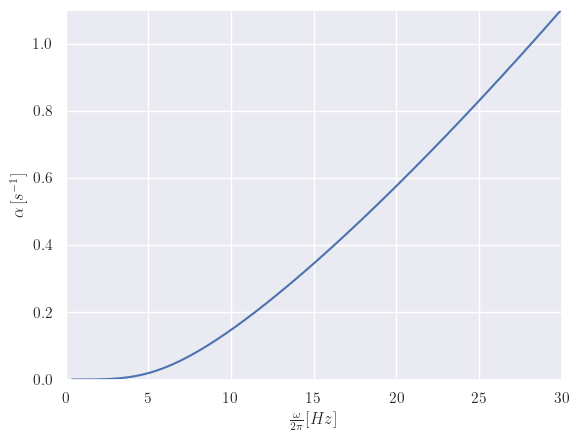

In [16]:
plt.plot(np.real(omegas)/(2*np.pi), -np.imag(omegas))
plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 1.1)
plt.ylabel(r"$\alpha \left[s^{-1}\right]$")

## Wave making theory

### evanescent modes

Text(0.5, 0, 'wavenumber $[cm^{-1}]$')

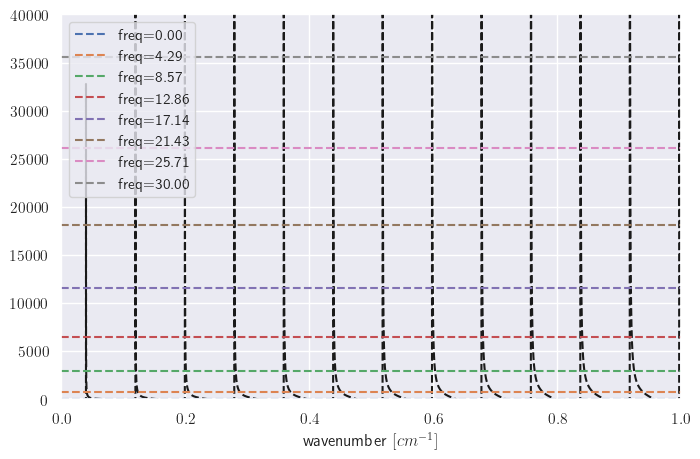

In [17]:
n_dense = int(1e5)
k_max = 2*np.pi*int(1e2) # m^-1
ks_dense = np.linspace(k_max/n_dense, k_max, num=n_dense).reshape((n_dense,1))
f_max = 30  # Hz


plt.figure(figsize=(8,5))

ks_dense_abs = norm(ks_dense, axis=-1)
plt.plot(
    ks_dense_abs/100,   # cm^-1
    (tau/rho * ks_dense_abs**3 - g0*ks_dense_abs)*np.tan(ks_dense_abs*H),
    '--k')

df = frequencies[-1]/n_dense
N = 8
freqs = np.linspace(df, f_max, num=N)
for i in range(N):
    freq = freqs[i]
    k = ks_dense_abs[i]
    plt.plot([0, k_max], [(2*pi*freq)**2]*2, '--', label=fr"freq={freq:.2f}")
# label=fr"$f_p = {freq:.2f}Hz$"
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 4e4)
plt.xlabel(r"wavenumber $[cm^{-1}]$")

In [18]:
pi/H

7.97358541520252

This seems to mean that 30cm away from the wave maker, all but the first
evanescent mode disappear. E.g. the second mode has $k \approx 0.12cm^{-1}$, so 
$k \cdot 30cm \approx 3.6$, which means that the mode decayed by a factor of
$e^{-3.6} \approx 2\%$ of the original amplitude. The first mode, on the other 
hand, seems to be at $k \approx 0.04cm^{-1}$ and so $k \cdot 30cm \approx 1.2$, 
which is still dominant with $70\%$ amplitude loss. The traveling mode, on the
other hand, say at the transition point with $\frac{\omega}{2 \pi} = 13.47Hz$ 
and $v_{phase} \approx 23\frac{cm}{s}$ has $\alpha \approx 0.3s^{-1}$, which 
means that at $30cm$ it has lost about $33\%$ of its amplitude, which is not too
bad. At $20Hz$, on the other hand, $\alpha \approx 0.6$ and the mode lost 
$\approx 50\%$ of its initial amplitude.

### mode amplitudes

variables: \omega_p, \alpha, d, S, M, N
parameters: h=H
remark: I do *not* normalize the height by H, so z is expected to be in the
range -H to 0.
remark: we work in the deep water limit, so tanh(h k_p) is dropped in the
expression for the dispersion (computation of k_p), and cosh(k_p (h + z)),
sinh(z (h + z)) are replaced with e^{k_p (h + z)} in compuing the travelin part 
of the velocity potential expression. I also extract e^{-h K_p} from A_p, 
A_{e,s}, for numerics sake.

In [19]:
def get_transition_point(k_abs_max, dk_abs=1e-1):
    return np.sqrt(rho*g0/tau)

In [ ]:


Z_MAX = 0

def alpha_func(z, d, alpha, h=H):
    """
    Piecewise alpha function.
    """
    z = np.asarray(z)
    a_per_z = np.empty_like(z, dtype=float)
    mask1 = (-d <= z) & (z <= 0)
    mask2 = (-h <= z) & (z < -d)

    a_per_z[mask1] = alpha
    a_per_z[mask2] = 0

    if not np.all(mask1 | mask2):
        raise ValueError("z out of range")
    
    return a_per_z.item() if np.isscalar(z) else a_per_z

# Propagating wave number k_p
def get_kp(w_p, h=H, tau=seawater_surface_tension):
    def dispersion_kp(k):
        return (g0*k + (tau/rho)*k**3) - w_p**2
    
    k_p_guess = w_p**2 / g0
    k_p_lbound = 0
    k_p_rbound = 1e4

    sol = sp.optimize.root_scalar(
        dispersion_kp, x0=k_p_guess, 
        bracket=[k_p_lbound, k_p_rbound],
        method="brentq"
        )

    # error checking
    if not sol.converged:
        raise RuntimeError(f"Root not found for k_p")

    return sol.root

# Evanescent modes k_{s,n}
def get_k_ns(w_p, N, h=H):
    def decay_kn(k, tau=seawater_surface_tension, rho = seasurface_density):
        return (-g0*k + (tau/rho)*k**3)*np.tan(k*h) - w_p**2

    k_equal = get_transition_point(k_abs_max=N*pi/h)
    k_ns = np.zeros(N)
    
    for n in range(1, N+1):
        # Approx first guess
        if (n-1/2)*pi/h < k_equal:
            k_guess = (n-1/4)*np.pi/h   # tan is decreasing to the right
        else:
            k_guess = (n-3/4)*np.pi/h   # tan is decreasing to the left
        
        delta = pi / (4*h) * (1-1e-3)
        k_lbound  = k_guess - delta
        k_rbound = k_guess + delta
        # print(k_lbound, k_rbound)
        # print((-g0*k_lbound + (tau/rho)*k_lbound**3)*np.tan(k_lbound*h) - w_p**2)
        # print((-g0*k_rbound + (tau/rho)*k_rbound**3)*np.tan(k_rbound*h) - w_p**2)

        # find 0
        sol = sp.optimize.root_scalar(
            decay_kn, x0=k_guess, bracket=[k_lbound, k_rbound], method="brentq"
            )
        
        # error checking
        if not sol.converged:
            raise RuntimeError(f"Root not found for n={n}")
        
        k_ns[n-1] = sol.root
        
    return k_ns

def B_m0(z_ms, k_p, alpha, d, h=H):
    a = alpha_func(z_ms, d, alpha)
    print(k_p/(2*pi), h, 1 + z_ms[-1],
        np.cosh(k_p * h * (1 + z_ms/h)))
    return k_p * (1j - np.tan(a)) * np.exp(
        k_p * h * (1 + z_ms/h) + 1j * k_p * h * np.tan(a) * (d/h + z_ms/h)
        )

def B_mn(z_m, k_n, alpha, d, h=H):
    a = alpha_func(z_m, d, alpha)
    return -k_n * (
        np.cos(k_n * h * (1 + z_m/h)) 
        - np.tan(a) * np.sin(k_n * h * (1 + z_m/h))
    ) * np.exp(-k_n * h * np.tan(a) * (d/h + z_m/h))

def get_zs(M, z_min=-H, z_max=0):
    zs = np.flip(np.linspace(z_min, z_max, M))
    return zs

def construct_B(w_p, N, M, alpha, d, h=H):
    z_ms = get_zs(M, z_min=-h, z_max=0)
    k_p = get_kp(w_p)
    k_ns = get_k_ns(w_p, N)
    zs_mesh, ks_mesh = np.meshgrid(z_ms, k_ns)
    B = np.zeros([1+N, M], dtype='complex')
    B[0,:] = B_m0(z_ms, k_p, alpha, d, h)
    B[1:,:] = B_mn(zs_mesh, ks_mesh, alpha, d, h)
    print(B[0,:])
    return B

def construct_D(S, w_p, M, d, alpha, h=H):
    z_ms = get_zs(M, z_min=-h, z_max=0)
    a = alpha_func(z_ms, d, alpha)
    return - S * w_p * np.tan(a)

def compute_A_exact(
        f_p:float, N: int, S:float, d: float, alpha: float, h=H
        ):
    B = construct_B(w_p=2*pi*f_p, M=N+1, N=N, alpha=alpha, d=d, h=h)
    D = construct_D(S=S, w_p=2*pi*f_p, M=N+1, d=d, alpha=alpha)
    print(B.shape, D.shape)
    return (np.linalg.lstsq(B, D, rcond=None))



In [161]:
stroke = 5e-3    # meters
mean_depth = 1e-2    # meters
f_plunger = 20    # Hz
w_plunger = 2*pi*f_plunger
wedge_tip_angle = pi/6
k_p = get_kp(f_plunger)

N = 31
k_n = get_k_ns(w_plunger, N)
ks = np.concatenate(([k_p], k_n))

A, res, rank, s = compute_A_exact(
    f_p=f_plunger, N=N, S=stroke, d=mean_depth, alpha=wedge_tip_angle, h=H
    )
mode_amplitudes = np.abs(1j*(ks/(2*pi*f_plunger))*A) * 1e2  # value in cm

N_dense = 127
k_ns_dense = get_k_ns(w_plunger, N_dense)
ks_dense = np.concatenate(([k_p], k_ns_dense))

# A_dense = compute_A_exact(
#     f_p=f_plunger, N=N_dense, S=stroke, d=mean_depth, alpha=wedge_tip_angle, h=H
#     )
# mode_amplitudes_dense = np.abs(1j*(ks_dense/(2*pi*f_plunger))*A_dense) * 1e2  # value in cm


# N_superdense = 255
# k_ns_superdense = get_k_ns(w_plunger, N_superdense)
# ks_superdense = np.concatenate(([k_p], k_ns_superdense))

# A_superdense = compute_A_exact(
#     f_p=f_plunger, N=N_superdense, S=stroke, d=mean_depth, alpha=wedge_tip_angle, h=H
#     )
# mode_amplitudes_superdense = np.abs(1j*(ks_superdense/(2*pi*f_plunger))*A_superdense) * 1e2  # value in cm

83.3814003963152 0.394 0.606 [2.21154363e+89 2.83725203e+86 3.63999107e+83 4.66984775e+80
 5.99108008e+77 7.68612649e+74 9.86074959e+71 1.26506352e+69
 1.62298586e+66 2.08217458e+63 2.67128080e+60 3.42706187e+57
 4.39667484e+54 5.64061881e+51 7.23650979e+48 9.28392358e+45
 1.19106088e+43 1.52804577e+40 1.96037324e+37 2.51501841e+34
 3.22658843e+31 4.13948177e+28 5.31065853e+25 6.81319440e+22
 8.74084026e+19 1.12138718e+17 1.43865941e+14 1.84569694e+11
 2.36789694e+08 3.03784211e+05 3.89734019e+02 1.00000000e+00]
[5.29295418e+91-1.22871585e+92j 0.00000000e+00+1.48643858e+89j
 0.00000000e+00+1.90699420e+86j 0.00000000e+00+2.44653692e+83j
 0.00000000e+00+3.13873158e+80j 0.00000000e+00+4.02676774e+77j
 0.00000000e+00+5.16605450e+74j 0.00000000e+00+6.62767779e+71j
 0.00000000e+00+8.50283574e+68j 0.00000000e+00+1.09085290e+66j
 0.00000000e+00+1.39948612e+63j 0.00000000e+00+1.79544042e+60j
 0.00000000e+00+2.30342142e+57j 0.00000000e+00+2.95512465e+54j
 0.00000000e+00+3.79121319e+51j 0.0000000

In [128]:
A

array([ 5.45959625e-219+4.23314633e-220j,
       -7.49848407e-242+5.51795971e-226j,
        4.80847340e-249+6.42043349e-233j,
        4.50000131e-256+7.47050873e-240j,
        4.73373781e-264+8.69232596e-247j,
        4.80649299e-270+1.01139739e-253j,
       -4.87522055e-277+1.17681354e-260j,
        1.19551743e-283+1.36928384e-267j,
        6.69650622e-292+1.59323306e-274j,
        2.03072097e-298+1.85380963e-281j,
       -2.61300491e-305+2.15700405e-288j,
        1.88036395e-311+2.50978655e-295j,
       -1.51400488e-318+2.92026735e-302j,
        0.00000000e+000+3.39788314e-309j,
       -0.00000000e+000+3.95361404e-316j,
        0.00000000e+000+4.44659081e-323j,
       -0.00000000e+000+0.00000000e+000j,
        0.00000000e+000+0.00000000e+000j,
        0.00000000e+000+0.00000000e+000j,
        0.00000000e+000+0.00000000e+000j,
        0.00000000e+000+0.00000000e+000j,
        0.00000000e+000+0.00000000e+000j,
        0.00000000e+000+0.00000000e+000j,
        0.00000000e+000+0.00000000

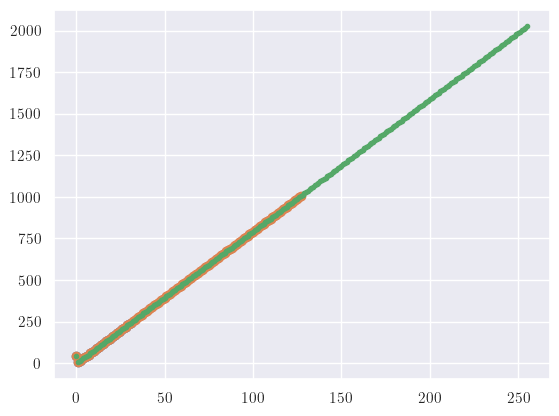

In [35]:
plt.plot(ks, 'o')
plt.plot(ks_dense, 'o')
plt.plot(ks_superdense, '.')


In [130]:
construct_D(S=stroke, w_p=2*pi*f_plunger, M=N+1, d=mean_depth, alpha=wedge_tip_angle)
construct_B(w_p=2*pi*f_plunger, N=N, M=N+1, alpha=wedge_tip_angle, d=mean_depth)


1256.256761008676 0.394 0.606 [4.56677267e+214 5.31367783e+207 6.18274088e+200 7.19394100e+193
 8.37052500e+186 9.73954176e+179 1.13324641e+173 1.31859121e+166
 1.53424954e+159 1.78517924e+152 2.07714902e+145 2.41687106e+138
 2.81215534e+131 3.27208919e+124 3.80724618e+117 4.42992920e+110
 5.15445333e+103 5.99747489e+096 6.97837437e+089 8.11970200e+082
 9.44769613e+075 1.09928865e+069 1.27907959e+062 1.48827571e+055
 1.73168630e+048 2.01490719e+041 2.34444945e+034 2.72788903e+027
 3.17404095e+020 3.69316195e+013 4.29718626e+006 1.00000000e+000]
[-6.60473859e+217+5.12104259e+216j  0.00000000e+000+6.67534370e+210j
  0.00000000e+000+7.76711003e+203j  0.00000000e+000+9.03743702e+196j
  0.00000000e+000+1.05155286e+190j  0.00000000e+000+1.22353652e+183j
  0.00000000e+000+1.42364846e+176j  0.00000000e+000+1.65648912e+169j
  0.00000000e+000+1.92741136e+162j  0.00000000e+000+2.24264349e+155j
  0.00000000e+000+2.60943250e+148j  0.00000000e+000+3.03621061e+141j
  0.00000000e+000+3.53278916e+134j 

array([[-6.60473859e+217+5.12104259e+216j,
         0.00000000e+000+6.67534370e+210j,
         0.00000000e+000+7.76711003e+203j, ...,
         0.00000000e+000+4.63955966e+016j,
         0.00000000e+000+5.39836929e+009j,
         0.00000000e+000+1.25625676e+003j],
       [ 2.26253609e+000+0.00000000e+000j,
        -1.92676896e-001+0.00000000e+000j,
        -3.94758299e-001+0.00000000e+000j, ...,
        -3.97253384e+000+0.00000000e+000j,
        -3.98794446e+000+0.00000000e+000j,
        -3.99308574e+000+0.00000000e+000j],
       [-6.53693375e+000+0.00000000e+000j,
         1.72878980e+000+0.00000000e+000j,
         3.50659999e+000+0.00000000e+000j, ...,
        -1.14281413e+001+0.00000000e+000j,
        -1.18406628e+001+0.00000000e+000j,
        -1.19792387e+001+0.00000000e+000j],
       ...,
       [ 4.04331099e+001+0.00000000e+000j,
        -7.50875143e+001+0.00000000e+000j,
         1.25985293e+002+0.00000000e+000j, ...,
        -1.99491496e+002+0.00000000e+000j,
         2.20360701

In [68]:
mode_amplitudes

array([8.69439505e-092, 9.57274692e-096, 3.68433883e-098, 7.87788020e-101,
       1.41493926e-103, 2.33389860e-106, 3.65957967e-109, 5.54855956e-112,
       8.21345477e-115, 1.19420965e-117, 1.71230702e-120, 2.42796849e-123,
       3.41150995e-126, 4.75721971e-129, 6.59129428e-132, 9.08234544e-135,
       1.24552984e-137, 1.70097588e-140, 2.31442644e-143, 3.13882810e-146,
       4.24443843e-149, 5.72438274e-152, 7.70196946e-155, 1.03403142e-157,
       1.38549933e-160, 1.85306707e-163, 2.47429334e-166, 3.29869519e-169,
       4.39150794e-172, 5.83861525e-175, 7.75302354e-178, 2.05665258e-180])

Text(0, 0.5, 'mode amplitude [cm]')

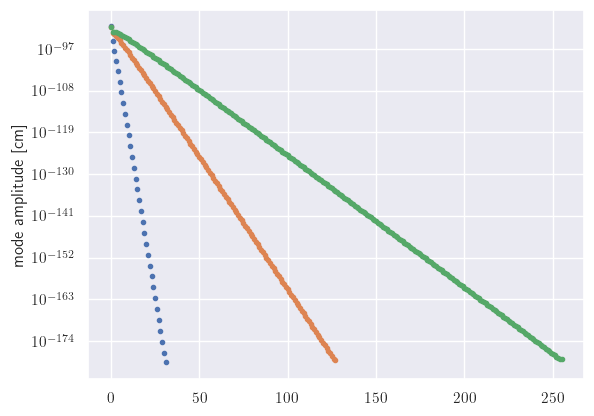

In [74]:
plt.semilogy(mode_amplitudes, '.')   # print in cm.
plt.semilogy(mode_amplitudes_dense, '.')   # print in cm.
plt.semilogy(mode_amplitudes_superdense, '.')   # print in cm.

# plt.xlim(0, 50)
# plt.ylim(1e-5)

plt.ylabel(r"mode amplitude [cm]")

Text(0, 0.5, 'mode amplitude [cm]')

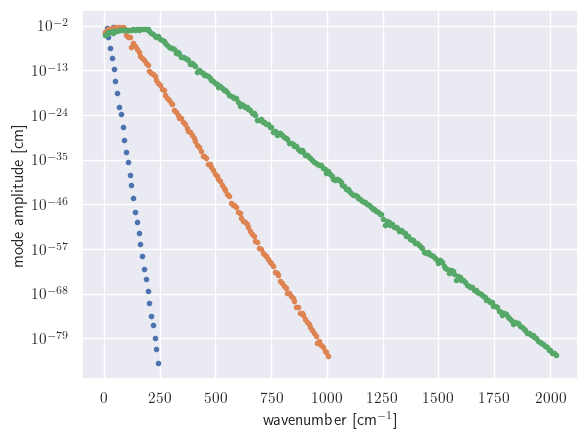

In [59]:
plt.semilogy(ks, mode_amplitudes, '.')   # print in cm.
plt.semilogy(ks_dense, mode_amplitudes_dense, '.')   # print in cm.
plt.semilogy(ks_superdense, mode_amplitudes_superdense, '.')   # print in cm.

# plt.ylim(1e-5)
plt.xlabel(r"wavenumber [cm$^{-1}$]")
plt.ylabel(r"mode amplitude [cm]")

In [ ]:
# Example usage
B0 = B_m0(k_p, H, z_m, alpha_val, d)
Bn = B_mn(k_s_n, H, z_m, alpha_val, d)
D = D_m(S, omega_p, z_m, d, alpha_val)

# Amplitudes
A0 = A_p = 1.0
An = A_s_n = 0.5

In [ ]:
def dispersion_kp(k):
    return (g0*k + (tau/rho)*k**3)*np.tanh(k*H) - w_plunger**2

k_p_guess = w_plunger**2 / g0
delta = pi / (4*h) * (1-1e-3)
    k_lbound  = k_p_guess - delta
    k_rbound = k_p_guess + delta
    # print(k_lbound, k_rbound)
    # print((-g0*k_lbound + (tau/rho)*k_lbound**3)*np.tan(k_lbound*h) - w_p**2)
    # print((-g0*k_rbound + (tau/rho)*k_rbound**3)*np.tan(k_rbound*h) - w_p**2)

    # find 0
    sol = sp.optimize.root_scalar(
        decay_kn, x0=k_guess, bracket=[k_lbound, k_rbound], method="brentq"
        )
k_p = sp.optimize.fsolve(dispersion_kp, x0=k_p_guess)[0]
g0*k*np.tanh(k_p*H) + (tau/rho)*k_p**3 - w_plunger**2

np.float64(-5137.218744908463)